# Forensic Linguistics: Speaker Profiling & Acoustic Analysis

**Author:** Niko Gamulin, PhD | **Date:** March 2026 | **License:** MIT

## This is NOT Lie Detection

**The measurements here are descriptive signal properties, not indicators of truthfulness or deception.**

- **F0 Variability Index (FVI)**: Frame-to-frame pitch variation. NOT clinical jitter. NOT a stress indicator.
- **Speech rate**: Words per minute. Does NOT indicate cognitive load.
- **Hedging language**: Uncertainty markers. Does NOT indicate dishonesty.
- **Assertiveness**: Power/hedging ratio. Does NOT indicate truthfulness.

Voice Stress Analysis (VSA) is not validated for forensic deception detection (NRC, 2003). We present acoustic measurements as **descriptive speaker profiles** for comparison and documentation purposes only.

See [DISCLAIMERS.md](../docs/DISCLAIMERS.md) for the full methodological statement.


In [1]:
import sys
sys.path.insert(0, '.')
from style import apply_style, COLORS, PALETTE
apply_style()

import numpy as np
import json
import matplotlib.pyplot as plt
from IPython.display import Image, display
import io, os

FIGURE_DIR = '../figures/linguistics/'
os.makedirs(FIGURE_DIR, exist_ok=True)

with open('../data/forensic_linguistics.json') as f:
    fl = json.load(f)

speakers_data = fl['per_speaker']
print(f"Speakers analyzed: {len(speakers_data)}")
for name in speakers_data:
    d = speakers_data[name]
    print(f"  {name}: {d.get('total_words',0)} words, {d.get('wpm',0):.0f} WPM")


Speakers analyzed: 6
  Dominika Švarc Pipan: 1620 words, 92 WPM
  Rok Hodej: 1175 words, 104 WPM
  Tomislav Vukmanović: 810 words, 136 WPM
  Vesna Vuković: 561 words, 104 WPM
  Nina Zidar Klemenčič: 947 words, 109 WPM
  Dejan Paravan: 433 words, 87 WPM


  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Comparative Speaker Profiles

In [2]:
features = ['total_words', 'wpm', 'ttr', 'guiraud', 'hedge_rate', 'power_rate', 'assertiveness']
labels = ['Total words', 'WPM', 'Type-Token Ratio', 'Guiraud Index', 'Hedging %', 'Power lang %', 'Assertiveness']

print(f"{'Feature':<22}", end='')
for name in speakers_data:
    print(f"{name.split()[-1]:>13}", end='')
print()
print("-" * (22 + 13 * len(speakers_data)))

for feat, label in zip(features, labels):
    print(f"{label:<22}", end='')
    for data in speakers_data.values():
        val = data.get(feat, 0)
        print(f"{val:>13.2f}" if isinstance(val, float) else f"{val:>13}", end='')
    print()


Feature                       Pipan        Hodej   Vukmanović      Vuković    Klemenčič      Paravan
----------------------------------------------------------------------------------------------------
Total words                    1620         1175          810          561          947          433
WPM                           91.51       104.15       135.94       103.57       108.77        87.47
Type-Token Ratio               0.39         0.41         0.33         0.43         0.36         0.50
Guiraud Index                 15.80        13.92         9.31        10.13        11.05        10.43
Hedging %                      1.74         2.98         1.11         1.74         3.05         0.69
Power lang %                   0.93         1.60         0.12         1.74         0.19         0.92
Assertiveness                  0.34         0.42         0.10         0.50         0.08         0.57


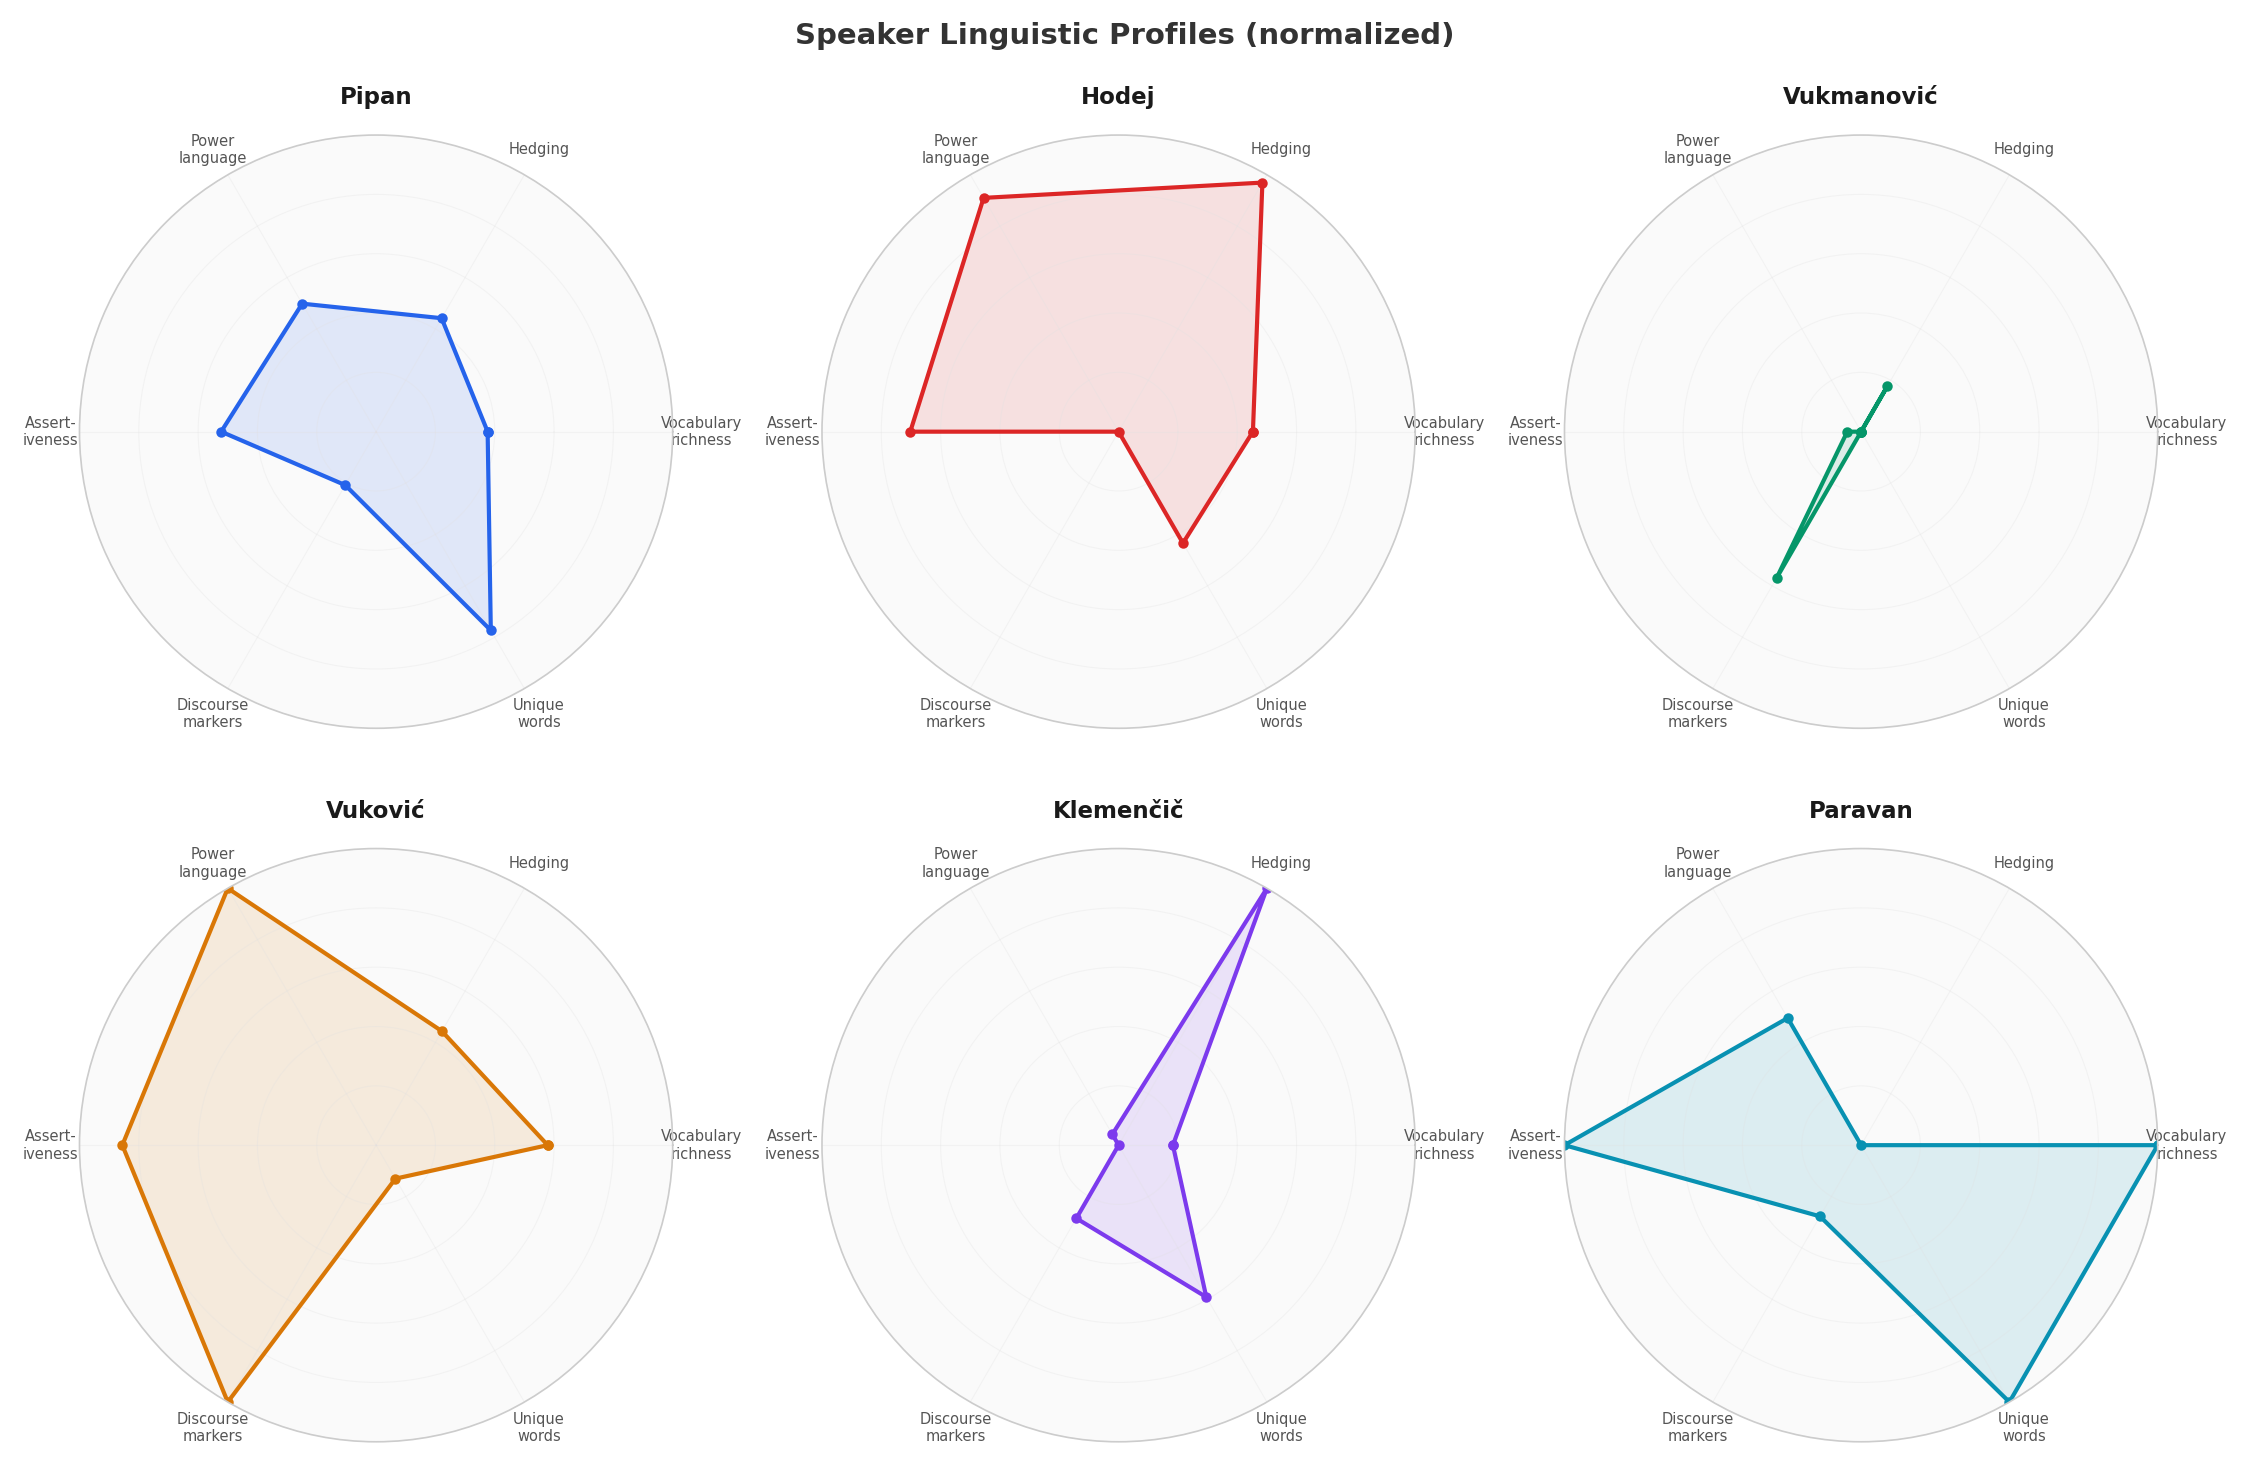

In [3]:
# Radar charts - one per speaker
fig, axes = plt.subplots(2, 3, figsize=(15, 10), subplot_kw=dict(projection='polar'))
axes = axes.flatten()

radar_feats = ['ttr', 'hedge_rate', 'power_rate', 'assertiveness', 'discourse_rate', 'hapax_ratio']
radar_labels = ['Vocabulary\nrichness', 'Hedging', 'Power\nlanguage', 'Assert-\niveness', 'Discourse\nmarkers', 'Unique\nwords']

# Normalize
all_v = {f: [d.get(f, 0) for d in speakers_data.values()] for f in radar_feats}
mins = {f: min(v) for f, v in all_v.items()}
maxs = {f: max(v) for f, v in all_v.items()}

for idx, (name, data) in enumerate(speakers_data.items()):
    if idx >= 6: break
    ax = axes[idx]
    
    vals = []
    for f in radar_feats:
        v = data.get(f, 0)
        rng = maxs[f] - mins[f]
        vals.append((v - mins[f]) / rng if rng > 0 else 0.5)
    
    angles = np.linspace(0, 2*np.pi, len(radar_feats), endpoint=False).tolist()
    vals_p = vals + [vals[0]]
    angles_p = angles + [angles[0]]
    
    color = PALETTE[idx]
    ax.plot(angles_p, vals_p, 'o-', linewidth=2, color=color, markersize=4)
    ax.fill(angles_p, vals_p, alpha=0.12, color=color)
    ax.set_xticks(angles)
    ax.set_xticklabels(radar_labels, fontsize=7)
    ax.set_title(name.split()[-1], fontsize=11, fontweight='bold', pad=15)
    ax.set_ylim(0, 1)
    ax.set_yticklabels([])
    ax.grid(True, alpha=0.3)

fig.suptitle('Speaker Linguistic Profiles (normalized)', fontsize=14, fontweight='bold')
plt.tight_layout()

buf = io.BytesIO()
fig.savefig(buf, format='png', dpi=150)
fig.savefig(os.path.join(FIGURE_DIR, 'speaker_profiles_radar.png'), dpi=150)
plt.close()
display(Image(data=buf.getvalue()))


## Speech Rate vs. Vocabulary Richness

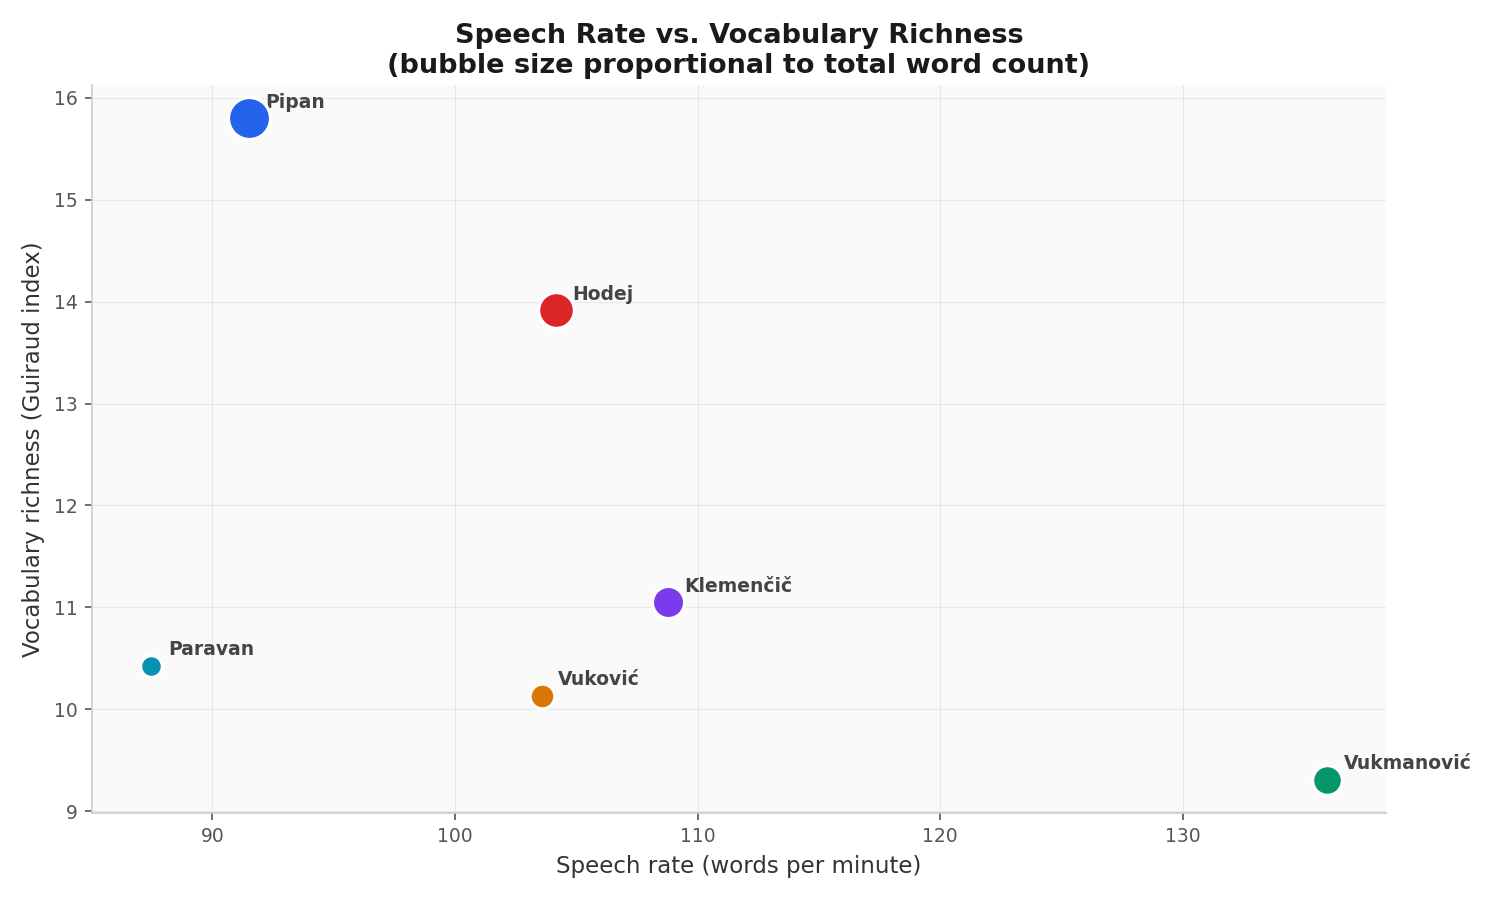

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

for idx, (name, data) in enumerate(speakers_data.items()):
    wpm = data.get('wpm', 0)
    guiraud = data.get('guiraud', 0)
    size = max(data.get('total_words', 100) / 4, 40)
    ax.scatter(wpm, guiraud, s=size, color=PALETTE[idx], zorder=5, edgecolors='white', linewidth=1.5)
    ax.annotate(name.split()[-1], (wpm, guiraud), textcoords="offset points",
                xytext=(8, 5), fontsize=9, fontweight='bold', color='#444444')

ax.set_xlabel('Speech rate (words per minute)')
ax.set_ylabel('Vocabulary richness (Guiraud index)')
ax.set_title('Speech Rate vs. Vocabulary Richness\n(bubble size proportional to total word count)')
plt.tight_layout()

buf = io.BytesIO()
fig.savefig(buf, format='png', dpi=150)
fig.savefig(os.path.join(FIGURE_DIR, 'wpm_vs_guiraud.png'), dpi=150)
plt.close()
display(Image(data=buf.getvalue()))


## Hedging vs. Power Language

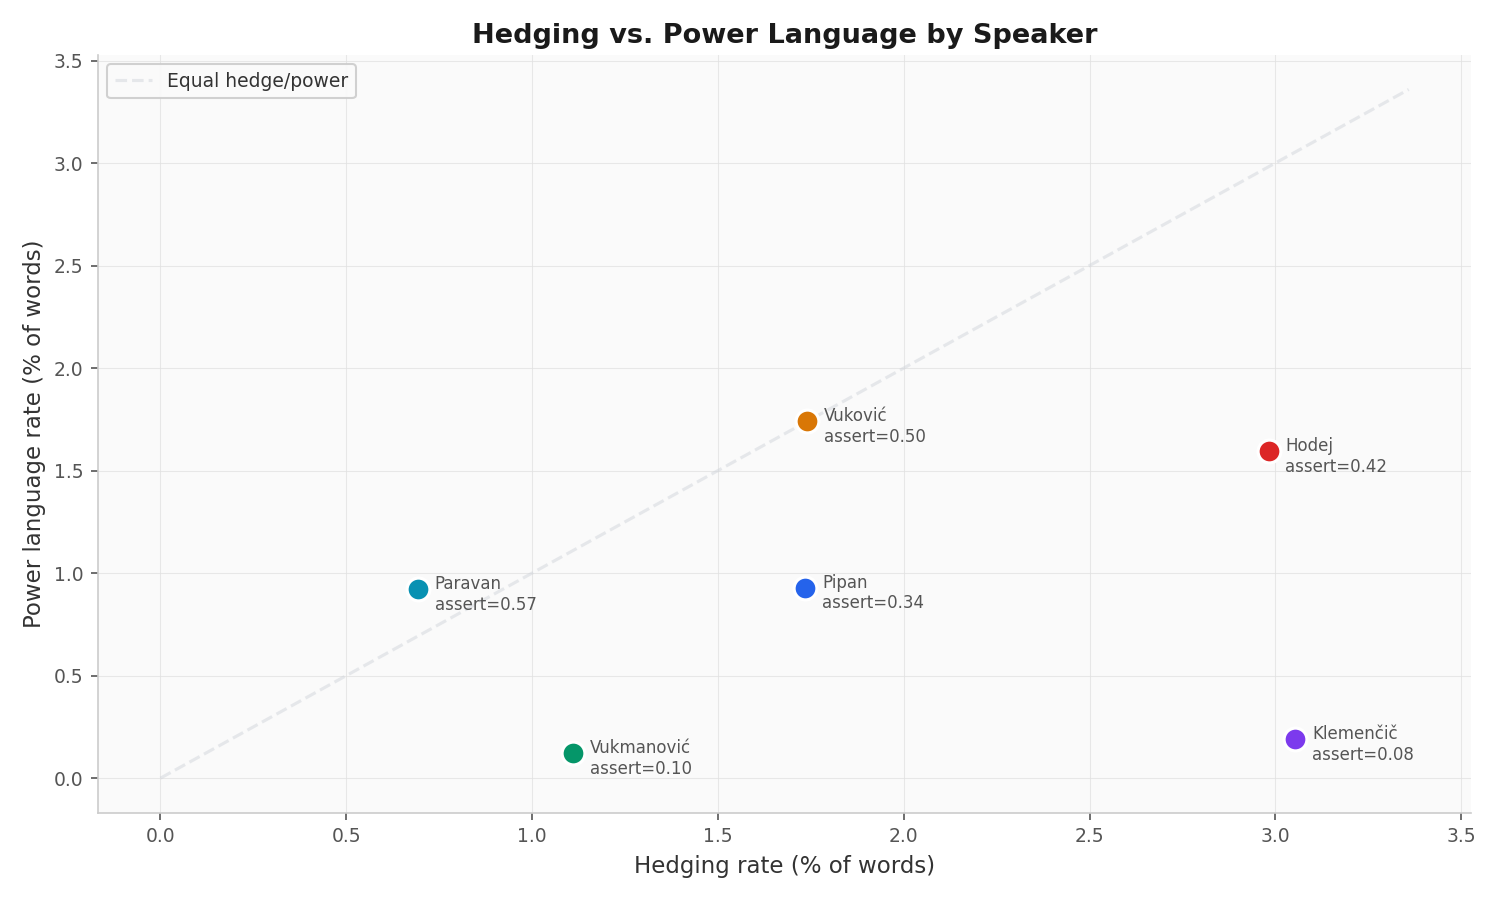

These are DESCRIPTIVE linguistic features, not deception indicators.


In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

for idx, (name, data) in enumerate(speakers_data.items()):
    h = data.get('hedge_rate', 0)
    p = data.get('power_rate', 0)
    a = data.get('assertiveness', 0)
    ax.scatter(h, p, s=120, color=PALETTE[idx], zorder=5, edgecolors='white', linewidth=1.5)
    ax.annotate(f"{name.split()[-1]}\nassert={a:.2f}", (h, p), textcoords="offset points",
                xytext=(8, -10), fontsize=8, color='#555555')

mx = max(max(d.get('hedge_rate',0) for d in speakers_data.values()),
         max(d.get('power_rate',0) for d in speakers_data.values()))
ax.plot([0, mx*1.1], [0, mx*1.1], '--', color=COLORS['light_gray'], alpha=0.5, label='Equal hedge/power')
ax.set_xlabel('Hedging rate (% of words)')
ax.set_ylabel('Power language rate (% of words)')
ax.set_title('Hedging vs. Power Language by Speaker')
ax.legend(fontsize=9)
plt.tight_layout()

buf = io.BytesIO()
fig.savefig(buf, format='png', dpi=150)
fig.savefig(os.path.join(FIGURE_DIR, 'hedge_vs_power.png'), dpi=150)
plt.close()
display(Image(data=buf.getvalue()))

print("These are DESCRIPTIVE linguistic features, not deception indicators.")


## What These Profiles Tell Us (and What They Don't)

### What they show:
- **Speaker consistency**: Each speaker maintains a relatively consistent linguistic profile across recordings. This supports authenticity -- fabricated speech would need to replicate these subtle patterns.
- **Natural variation**: Genuine individual differences in vocabulary, rate, and language use.
- **Context effects**: Some variation for the same speaker across recordings reflects different conversational contexts.

### What they do NOT show:
- Whether any speaker is telling the truth
- Whether any speaker is under stress
- Whether any recording has been manipulated (see Notebook 01)

### On FVI (F0 Variability Index)

FVI values (5-20%) measure frame-to-frame F0 variation across 10ms windows. This is NOT clinical jitter (cycle-to-cycle perturbation at glottal pulse level). Clinical jitter above 1% indicates vocal pathology. Our FVI operates on a completely different scale measuring a different phenomenon. **Comparing FVI to clinical jitter norms is a category error.**
